<a href="https://colab.research.google.com/github/juanfloresponce2006-dot/Creaci-n-y-Visualizaci-n-de-KPI-s/blob/main/Examen_2B_Practio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2487/836301129.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=prices, ax=ax1, palette='viridis')
/tmp/ipykernel_2487/836301129.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=room_diffs, ax=ax4, palette='coolwarm')


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

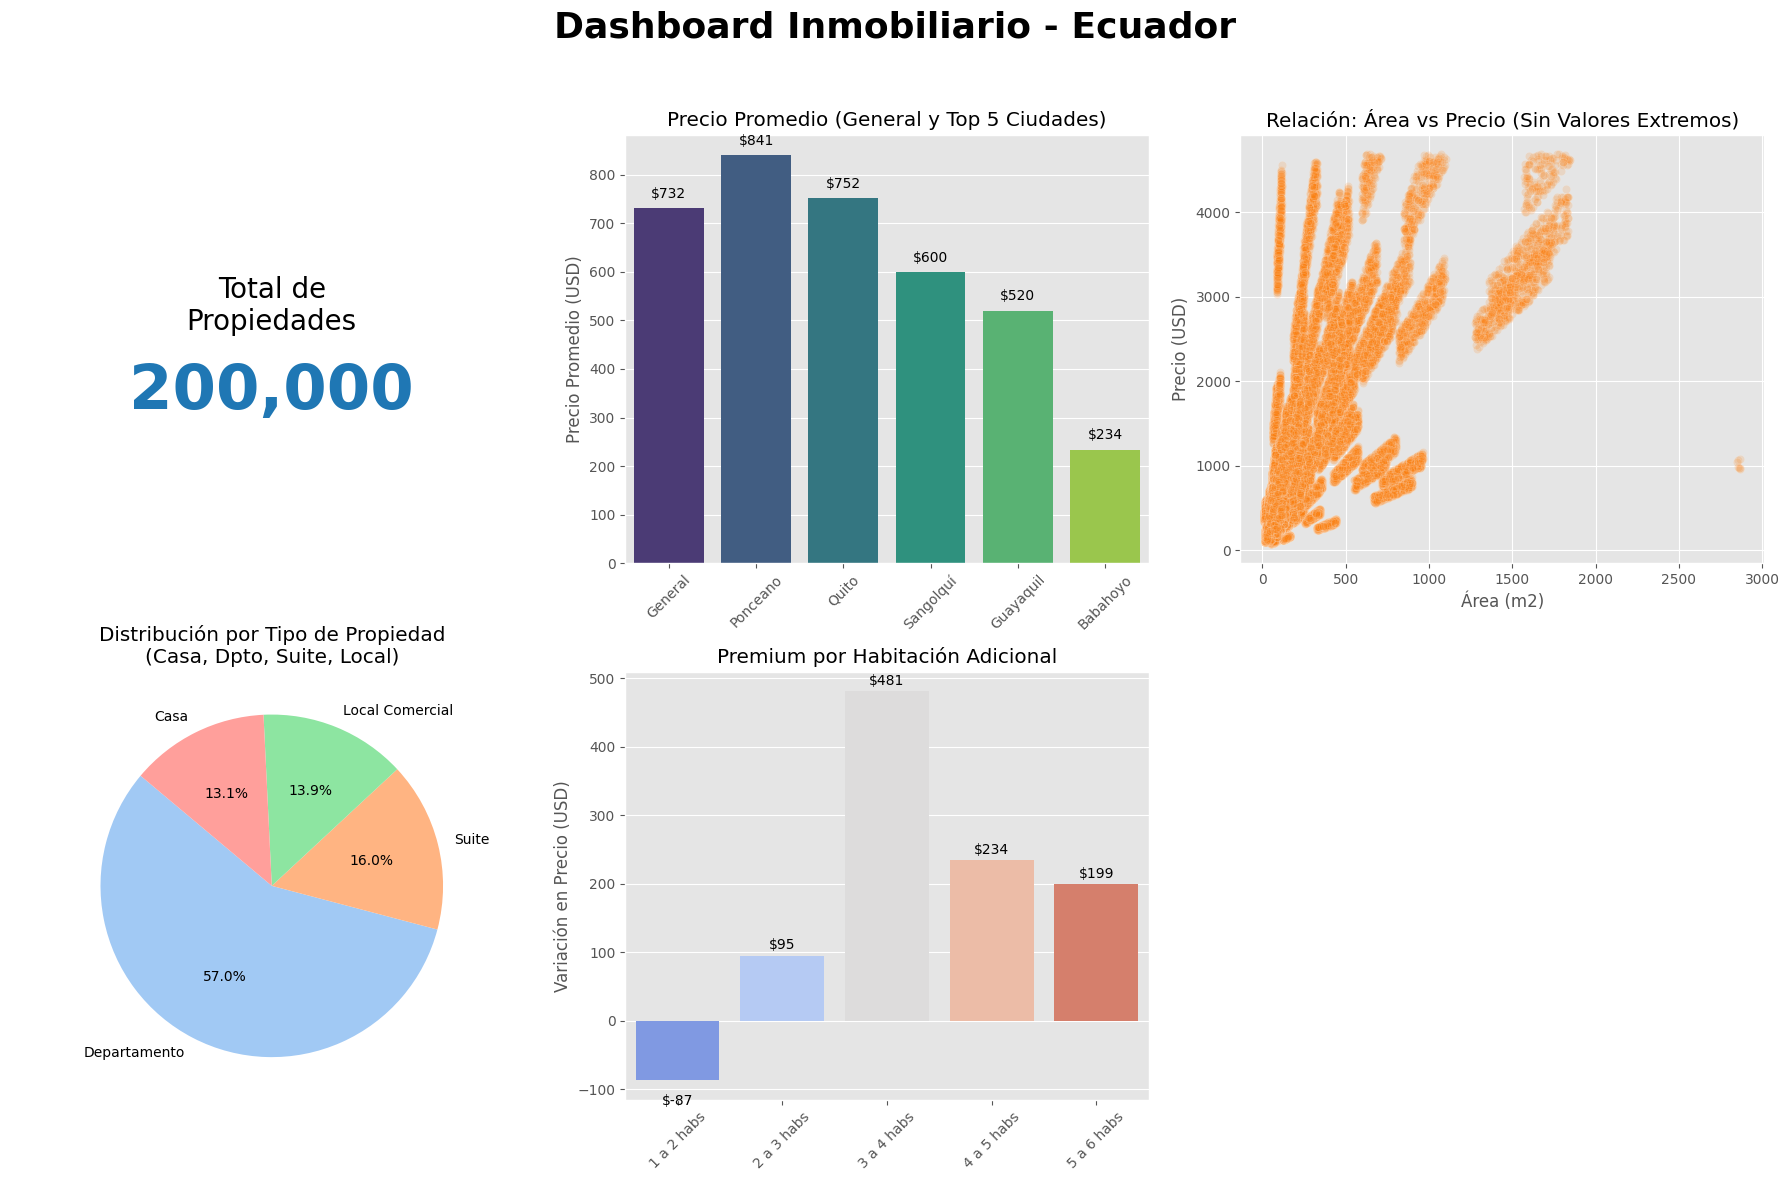

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

# Funciones de limpieza
def extract_city(lugar):
    parts = [p.strip() for p in str(lugar).split(',')]
    if len(parts) >= 3 and parts[-1].lower() == 'ecuador':
        city_part = parts[-2]
        import re
        city_part = re.sub(r'\s*\d+', '', city_part).strip()
        return city_part
    return parts[-1] if len(parts)>0 else "Desconocido"

df['Ciudad'] = df['Lugar'].apply(extract_city)

def get_property_type(title):
    t = str(title).lower()
    if 'departamento' in t or 'dpto' in t: return 'Departamento'
    if 'casa' in t: return 'Casa'
    if 'suite' in t: return 'Suite'
    if 'local' in t: return 'Local Comercial'
    return 'Otro'

df['Tipo'] = df['Titulo'].apply(get_property_type)

# Setup de la figura principal
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard Inmobiliario - Ecuador', fontsize=26, fontweight='bold', y=0.98)

# Total de propiedades en número grande
ax0 = plt.subplot(2, 3, 1)
ax0.axis('off')
ax0.text(0.5, 0.6, 'Total de\nPropiedades', fontsize=20, ha='center', va='center')
ax0.text(0.5, 0.4, f"{len(df):,}", fontsize=45, fontweight='bold', color='#1f77b4', ha='center', va='center')

# gráfico de barras de precio promedio de alquiler general y por ciudad
ax1 = plt.subplot(2, 3, 2)
# 5 ciudades más frecuentes para comparadas con el general
top_cities_plot = df['Ciudad'].value_counts().head(5).index
city_prices = df[df['Ciudad'].isin(top_cities_plot)].groupby('Ciudad')['Precio'].mean().sort_values(ascending=False)
categories = ['General'] + list(city_prices.index)
prices = [df['Precio'].mean()] + list(city_prices.values)

sns.barplot(x=categories, y=prices, ax=ax1, palette='viridis')
ax1.set_title('Precio Promedio (General y Top 5 Ciudades)')
ax1.set_ylabel('Precio Promedio (USD)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(prices):
    ax1.text(i, v + 15, f'${v:.0f}', ha='center', va='bottom', fontsize=10)

# Gráfico de dispersión de la relación entre Área y Precio
ax2 = plt.subplot(2, 3, 3)
# Filtramos percentil 99 para evitar que los outliers extremos aplasten el gráfico
q_area = df['Area'].quantile(0.99)
q_precio = df['Precio'].quantile(0.99)
df_scatter = df[(df['Area'] < q_area) & (df['Precio'] < q_precio)]

sns.scatterplot(data=df_scatter, x='Area', y='Precio', alpha=0.15, ax=ax2, color='#ff7f0e')
ax2.set_title('Relación: Área vs Precio (Sin Valores Extremos)')
ax2.set_xlabel('Área (m2)')
ax2.set_ylabel('Precio (USD)')

# Gráfico de pastel de conteo de registros por Tipo
ax3 = plt.subplot(2, 3, 4)
# Casa, Departamento, Suite, Local Comercial
tipos_solicitados = ['Casa', 'Departamento', 'Suite', 'Local Comercial']
df_tipos = df[df['Tipo'].isin(tipos_solicitados)]
tipo_counts = df_tipos['Tipo'].value_counts()

ax3.pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
ax3.set_title('Distribución por Tipo de Propiedad\n(Casa, Dpto, Suite, Local)')

# Gráfico de Premium por Habitación Adicional
ax4 = plt.subplot(2, 3, 5)
df_rooms = df[df['Num. dormitorios'].between(1, 6)].copy()
room_prices = df_rooms.groupby('Num. dormitorios')['Precio'].mean()

room_diffs = []
labels = []
for i in range(1, len(room_prices)):
    r1 = room_prices.index[i-1]
    r2 = room_prices.index[i]
    diff = room_prices.iloc[i] - room_prices.iloc[i-1]
    labels.append(f"{int(r1)} a {int(r2)} habs")
    room_diffs.append(diff)

sns.barplot(x=labels, y=room_diffs, ax=ax4, palette='coolwarm')
ax4.set_title('Premium por Habitación Adicional')
ax4.set_ylabel('Variación en Precio (USD)')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(room_diffs):
    # Ajuste de posición del texto si es negativo o positivo
    offset = 15 if v > 0 else -30
    ax4.text(i, v + offset, f'${v:.0f}', ha='center', va='center', color='black', fontsize=10)

# Ajustar el layout general y eliminar el panel vacío (2,3,6)
plt.tight_layout(rect=[0, 0, 1, 0.95])
ax5 = plt.subplot(2, 3, 6)
ax5.axis('off')

In [ ]:
import pandas as pd
df = pd.read_csv("real_estate_ecuador_200k.csv")
df.tail()

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
199995,DEPARTAMENTO EN SAIBA,465.94,Guayas,"Guayas, Ciudadela Saiba, Guayaquil, Ecuador",2.0,3.0,104,NaN
199996,"Arriendo Departamento 2 Dormitorios, Mañosca",413.17,Pichincha,"Pichincha, Mañosca & Avenida Occidental, Quito...",3.0,3.0,119,1.0
199997,RENTA DEPARTAMENTO PONCIANO ALTO,458.20,Pichincha,"Pichincha,",3.0,2.0,182,1.0
199998,Hermoso departamento de arriendo duplex sector...,380.53,Pichincha,"Pichincha, Ponceano Alto, Quito, Ecuador",2.0,2.0,86,1.0
199999,Hermoso departamento de arriendo sector Poncea...,412.61,Pichincha,"Pichincha, Ponceano Alto, Quito, Ecuador",3.0,2.0,110,1.0


In [ ]:
#Perspectiva Financiera

# Extraer la ciudad
def extract_city(lugar):
    parts = [p.strip() for p in str(lugar).split(',')]
    if len(parts) >= 3 and parts[-1].lower() == 'ecuador':
        city_part = parts[-2]
        import re
        city_part = re.sub(r'\s*\d+', '', city_part).strip()
        return city_part
    return parts[-1] if len(parts)>0 else "Desconocido"

df['Ciudad'] = df['Lugar'].apply(extract_city)

# Precio Promedio de Alquiler
precio_general = df['Precio'].mean().round(2)
precio_ciudad = df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False)
# Top 10 de ciudades con más registros
top_cities_counts = df['Ciudad'].value_counts().head(10).index
precio_top_ciudades = df[df['Ciudad'].isin(top_cities_counts)].groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).round(2)

# Costo Promedio por Metro Cuadrado
df['Costo_m2'] = df['Precio'] / df['Area']
df['Costo_m2'].replace([np.inf, -np.inf], np.nan, inplace=True)
costo_m2_promedio = df['Costo_m2'].mean().round(2)

# Rango de Precios por Provincia
rango_provincia = df.groupby('Provincia')['Precio'].agg(['min', 'max', 'mean']).round(2)
rango_provincia = rango_provincia.sort_values(by='mean', ascending=False)

print(f"Precio promedio de alquiler general: {precio_general}")
print("\nCosto promedio or Ciudad:\n", precio_top_ciudades)
print(f"\nPrecio promedio por m²: {costo_m2_promedio}")
print("\nRango de Precios por Provincia:\n", rango_provincia)

Precio promedio de alquiler general: 732.35

Costo promedio or Ciudad:
 Ciudad
Samborondón                                   1798.55
San Rafael                                     865.37
Pifo                                           853.01
Ponceano                                       840.71
Quito                                          752.21
Sangolquí                                      599.58
Guayaquil                                      520.29
6º Pasaje 9 NO Kennedy Guayaquil Guayaquil     353.05
Babahoyo                                       233.59
Machala                                        124.35
Name: Precio, dtype: float64

Precio promedio por m²: 5.89

Rango de Precios por Provincia:
                  min       max     mean
Provincia                              
Manabí       5176.48   7920.44  6503.10
Cotopaxi       94.47   4557.66  1814.53
Pichincha      80.21  11062.33   734.51
Guayas        130.85   2816.34   614.67
Imbabura      380.54    589.42   480.81
Esmerald

/tmp/ipykernel_2487/3096075093.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Costo_m2'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [ ]:
#Perspectiva del producto

# Distribución por Tipo de Propiedad
def get_property_type(title):
    t = str(title).lower()
    if 'departamento' in t or 'dpto' in t: return 'Departamento'
    if 'casa' in t: return 'Casa'
    if 'suite' in t: return 'Suite'
    if 'local' in t: return 'Local Comercial'
    if 'oficina' in t: return 'Oficina'
    if 'terreno' in t or 'lote' in t: return 'Terreno'
    if 'galpon' in t or 'bodega' in t or 'galpón' in t: return 'Galpón/Bodega'
    if 'quinta' in t or 'hacienda' in t: return 'Quinta/Hacienda'
    return 'Otro'

df['Tipo'] = df['Titulo'].apply(get_property_type)
distribucion_tipo = df['Tipo'].value_counts()
print("Distribución por Tipo:")
print(distribucion_tipo)

# Tamaño Promedio por Provincia
tamano_promedio = df.groupby('Provincia')['Area'].mean().round(2).sort_values(ascending=False)
print("\nTamaño Promedio por Provincia (m2):")
print(tamano_promedio)

# Premium por Habitación Adicional
# Filtro por numero de habitaciones (1 a 6)
df_rooms = df[df['Num. dormitorios'].between(1, 6)].copy()
room_prices = df_rooms.groupby('Num. dormitorios')['Precio'].mean()
print("\nPrecio promedio por número de habitaciones:")
print(room_prices.round(2))

print("\nPremium por habitación:")
for i in range(1, len(room_prices)):
    r1 = int(room_prices.index[i-1])
    r2 = int(room_prices.index[i])
    diff = room_prices.iloc[i] - room_prices.iloc[i-1]
    print(f"De {r1} a {r2} habitaciones: ${diff:.2f}")

Distribución por Tipo:
Tipo
Departamento       87660
Suite              24640
Oficina            23124
Local Comercial    21301
Casa               20174
Otro               14263
Galpón/Bodega       5954
Terreno             2015
Quinta/Hacienda      869
Name: count, dtype: int64

Tamaño Promedio por Provincia (m2):
Provincia
Santa Elena    199727.40
El Oro           5947.77
Manabí            199.65
Pichincha         166.80
Imbabura          140.62
Esmeraldas        110.38
Guayas            103.34
Los Rios           88.95
Cotopaxi           72.43
Orellana           27.99
Name: Area, dtype: float64

Precio promedio por número de habitaciones:
Num. dormitorios
1.0     583.89
2.0     496.74
3.0     591.99
4.0    1073.33
5.0    1307.77
6.0    1506.98
Name: Precio, dtype: float64

Premium por habitación:
De 1 a 2 habitaciones: $-87.15
De 2 a 3 habitaciones: $95.25
De 3 a 4 habitaciones: $481.33
De 4 a 5 habitaciones: $234.45
De 5 a 6 habitaciones: $199.21


In [ ]:
#Perspectiva geográfica
# Extracción
def extract_city(lugar):
    parts = [p.strip() for p in str(lugar).split(',')]
    if len(parts) >= 3 and parts[-1].lower() == 'ecuador':
        city_part = parts[-2]
        import re
        city_part = re.sub(r'\s*\d+', '', city_part).strip()
        return city_part
    return parts[-1] if len(parts)>0 else "Desconocido"

df['Ciudad'] = df['Lugar'].apply(extract_city)

# Top 5 Ciudades/Sectores Más Caros
# Para evitar que una sola propiedad costosa distorsione el ranking,
# filtramos ciudades con al menos 10 registros
conteo_ciudades = df['Ciudad'].value_counts()
ciudades_validas = conteo_ciudades[conteo_ciudades >= 10].index

top5_caros = df[df['Ciudad'].isin(ciudades_validas)].groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(5)
print("Top 5 Ciudades/Sectores más caros:")
print(top5_caros.round(2))

print("\nTop 5 absoluto:")
print(df.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(5).round(2))

# Concentración de la Oferta
conteo_provincia = df['Provincia'].value_counts()
print("\nConcentración por Provincia:")
print(conteo_provincia)

conteo_ciudad_top10 = df['Ciudad'].value_counts().head(10)
print("\nConcentración por Ciudad (Top 10):")
print(conteo_ciudad_top10)

Top 5 Ciudades/Sectores más caros:
Ciudad
Manta                                 6503.10
Cotopaxi                              3697.69
SECTOR PLATAFORMA FINANCIERA NORTE    2086.73
Samborondón                           1798.55
Nayón Tanda Eugenio Espejo            1198.01
Name: Precio, dtype: float64

Top 5 absoluto:
Ciudad
Manta                                 6503.10
Cotopaxi                              3697.69
SECTOR PLATAFORMA FINANCIERA NORTE    2086.73
Samborondón                           1798.55
Nayón Tanda Eugenio Espejo            1198.01
Name: Precio, dtype: float64

Concentración por Provincia:
Provincia
Pichincha      180673
Guayas          13960
Los Rios         1288
Cotopaxi          859
Esmeraldas        804
El Oro            793
Manabí            416
Orellana          413
Imbabura          398
Santa Elena       396
Name: count, dtype: int64

Concentración por Ciudad (Top 10):
Ciudad
Quito                                         154211
Sangolquí                         

In [ ]:
#Segmentación de Mercado

Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)

print(f"Q1 (Cuartil 1): {Q1}")
print(f"Q3 (Cuartil 3): {Q3}")

def clasificar_mercado(precio):
    if precio < Q1:
        return "Económico"
    elif precio > Q3:
        return "Lujo"
    else:
        return "Medio"

df['Tipo de Inmueble'] = df['Precio'].apply(clasificar_mercado)
conteo = df['Tipo de Inmueble'].value_counts()
porcentaje = df['Tipo de Inmueble'].value_counts(normalize=True) * 100

print("\nConteo por segmento:")
print(conteo)
print("\nPorcentaje por segmento:")
print(porcentaje.round(2))

Q1 (Cuartil 1): 371.77
Q3 (Cuartil 3): 728.6424999999999

Conteo por segmento:
Tipo de Inmueble
Medio        100001
Lujo          50000
Económico     49999
Name: count, dtype: int64

Porcentaje por segmento:
Tipo de Inmueble
Medio        50.0
Lujo         25.0
Económico    25.0
Name: proportion, dtype: float64
